# Agentic AI - ML Sentiment Analysis Training Pipeline

This notebook covers the standalone training pipeline for our sentiment analysis models (Random Forest and LSTM) based on the `cleaned_review_text` and `recommended_ind` features from the Women's Clothing E-Commerce dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import joblib
import os
from dotenv import load_dotenv

# Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# TensorFlow / Keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, LSTM, Dense

sns.set_theme(style="whitegrid")

## 1. Database Connection & Data Loading
Fetching the `cleaned_review_text` (features) and `recommended_ind` (target) directly from PostgreSQL by dynamically loading credentials from the root `.env` file.

In [2]:
# Load environment variables from the root project directory
load_dotenv(dotenv_path='../.env')

db_user = os.getenv('DB_USER', 'postgres')
db_password = os.getenv('DB_PASSWORD', '')
db_host = os.getenv('DB_HOST', '127.0.0.1')
db_port = os.getenv('DB_PORT', '5432')
db_name = os.getenv('DB_NAME', 'postgres')

# Construct connection string and connect to PostgreSQL
DB_URL = f'postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}'
engine = create_engine(DB_URL)

# Fetch data
query = """
SELECT cleaned_review_text, recommended_ind 
FROM products_review 
WHERE cleaned_review_text IS NOT NULL AND cleaned_review_text != ''
"""
df = pd.read_sql(query, engine)

# Handle any remaining nulls
df = df.dropna()

print(f"Total reviews fetched: {len(df)}")
display(df.head())

Total reviews fetched: 22641


,cleaned_review_text,recommended_ind
0,absolut wonder silki sexi comfort,True
1,love dress sooo pretti happen find store glad ...,True
2,high hope dress realli want work initi order p...,False
3,love love love jumpsuit fun flirti fabul everi...,True
4,shirt flatter due adjust front tie perfect len...,True


In [3]:
# Train-Test Split (80/20)
X = df['cleaned_review_text'].values
y = df['recommended_ind'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (18112,)
Testing Set Shape: (4529,)


## 2. Model 1: Random Forest Pipeline
Vectorizing using TF-IDF and training a Random Forest Classifier.

Training Random Forest...

--- Random Forest Metrics ---
              precision    recall  f1-score   support

           0       0.68      0.58      0.63       820
           1       0.91      0.94      0.92      3709

    accuracy                           0.88      4529
   macro avg       0.80      0.76      0.78      4529
weighted avg       0.87      0.88      0.87      4529



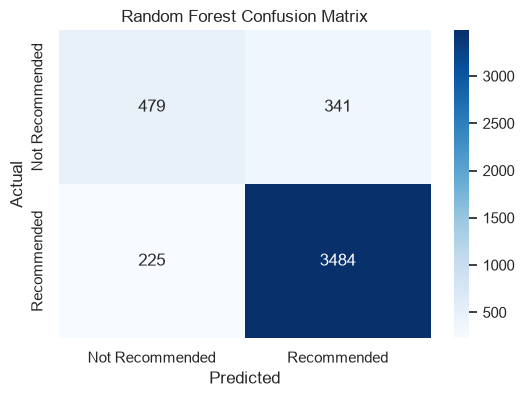

In [4]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train_rf = vectorizer.fit_transform(X_train)
X_test_rf = vectorizer.transform(X_test)

# Train Random Forest (Updated with class_weight='balanced')
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_rf, y_train)

# Evaluate
rf_preds = rf_model.predict(X_test_rf)
print("\n--- Random Forest Metrics ---")
print(classification_report(y_test, rf_preds))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Recommended', 'Recommended'], yticklabels=['Not Recommended', 'Recommended'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 3. Model 2: LSTM Pipeline
Using Keras Tokenizer and building a deep Sequential LSTM model.

In [5]:
# Tokenization and Padding
vocab_size = 10000
max_length = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

# Build LSTM Architecture
lstm_model = Sequential([
    Embedding(vocab_size, 64, input_length=max_length),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.summary()

D:\Projects\BilCode\ML - Agentic AI PR System\codebase\ml_training\ml_venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Train LSTM
epochs = 5
batch_size = 64

# Compute class weights dynamically based on y_train distribution
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}

print(f"Training LSTM with class weights: {class_weight_dict}...")
history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

Training LSTM with class weights: {0: np.float64(2.760134105455654), 1: np.float64(0.6106129054008496)}...
Epoch 1/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 30s 101ms/step - accuracy: 0.5137 - loss: 0.6978 - val_accuracy: 0.1706 - val_loss: 0.7179
Epoch 2/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - accuracy: 0.3447 - loss: 0.6974 - val_accuracy: 0.1706 - val_loss: 0.6953
Epoch 3/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 41s 95ms/step - accuracy: 0.2942 - loss: 0.6972 - val_accuracy: 0.8294 - val_loss: 0.6900
Epoch 4/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - accuracy: 0.3510 - loss: 0.6974 - val_accuracy: 0.1706 - val_loss: 0.7033
Epoch 5/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - accuracy: 0.3810 - loss: 0.6973 - val_accuracy: 0.1706 - val_loss: 0.7020


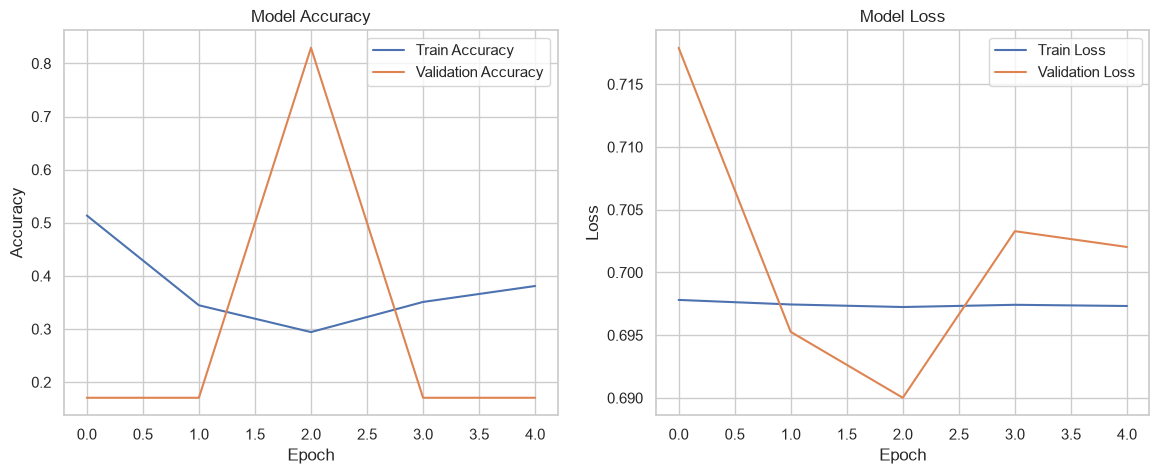

142/142 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step

--- LSTM Metrics ---
              precision    recall  f1-score   support

           0       0.18      1.00      0.31       820
           1       0.00      0.00      0.00      3709

    accuracy                           0.18      4529
   macro avg       0.09      0.50      0.15      4529
weighted avg       0.03      0.18      0.06      4529



D:\Projects\BilCode\ML - Agentic AI PR System\codebase\ml_training\ml_venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Projects\BilCode\ML - Agentic AI PR System\codebase\ml_training\ml_venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Projects\BilCode\ML - Agentic AI PR System\codebase\ml_training\ml_venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_d

In [7]:
# Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()

# Evaluate LSTM
lstm_preds_prob = lstm_model.predict(X_test_pad)
lstm_preds = (lstm_preds_prob > 0.5).astype(int)

print("\n--- LSTM Metrics ---")
print(classification_report(y_test, lstm_preds))

## 4. Model Export (CRITICAL)
Saving all trained models, vectorizers, and tokenizers to `ml_training/exported_models/`.

In [8]:
export_dir = 'exported_models'
os.makedirs(export_dir, exist_ok=True)

# Export Random Forest Artifacts
joblib.dump(rf_model, os.path.join(export_dir, 'rf_model.pkl'))
joblib.dump(vectorizer, os.path.join(export_dir, 'tfidf_vectorizer.pkl'))
print("Random Forest and TF-IDF Vectorizer exported.")

# Export LSTM Artifacts
lstm_model.save(os.path.join(export_dir, 'lstm_model.keras'))
joblib.dump(tokenizer, os.path.join(export_dir, 'lstm_tokenizer.pkl'))
print("LSTM Model and Tokenizer exported.")

print("All artifacts successfully saved to `exported_models/`.")

Random Forest and TF-IDF Vectorizer exported.
LSTM Model and Tokenizer exported.
All artifacts successfully saved to `exported_models/`.
